<a href="https://colab.research.google.com/github/tirthas970-cmyk/Galaxy-Classifier-Model/blob/main/notebook/Galaxy_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install astroNN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00


In [3]:
from astroNN.datasets import load_galaxy10sdss
import numpy as np
import tensorflow as tf
from keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras import mixed_precision

images, labels = load_galaxy10sdss()

Galaxy10.h5:  99%|█████████▉| 208M/210M [00:07<00:00, 33.7MB/s]

Downloaded Galaxy10 successfully to /root/.astroNN/datasets/Galaxy10.h5


Galaxy10.h5: 210MB [00:08, 25.5MB/s]                           


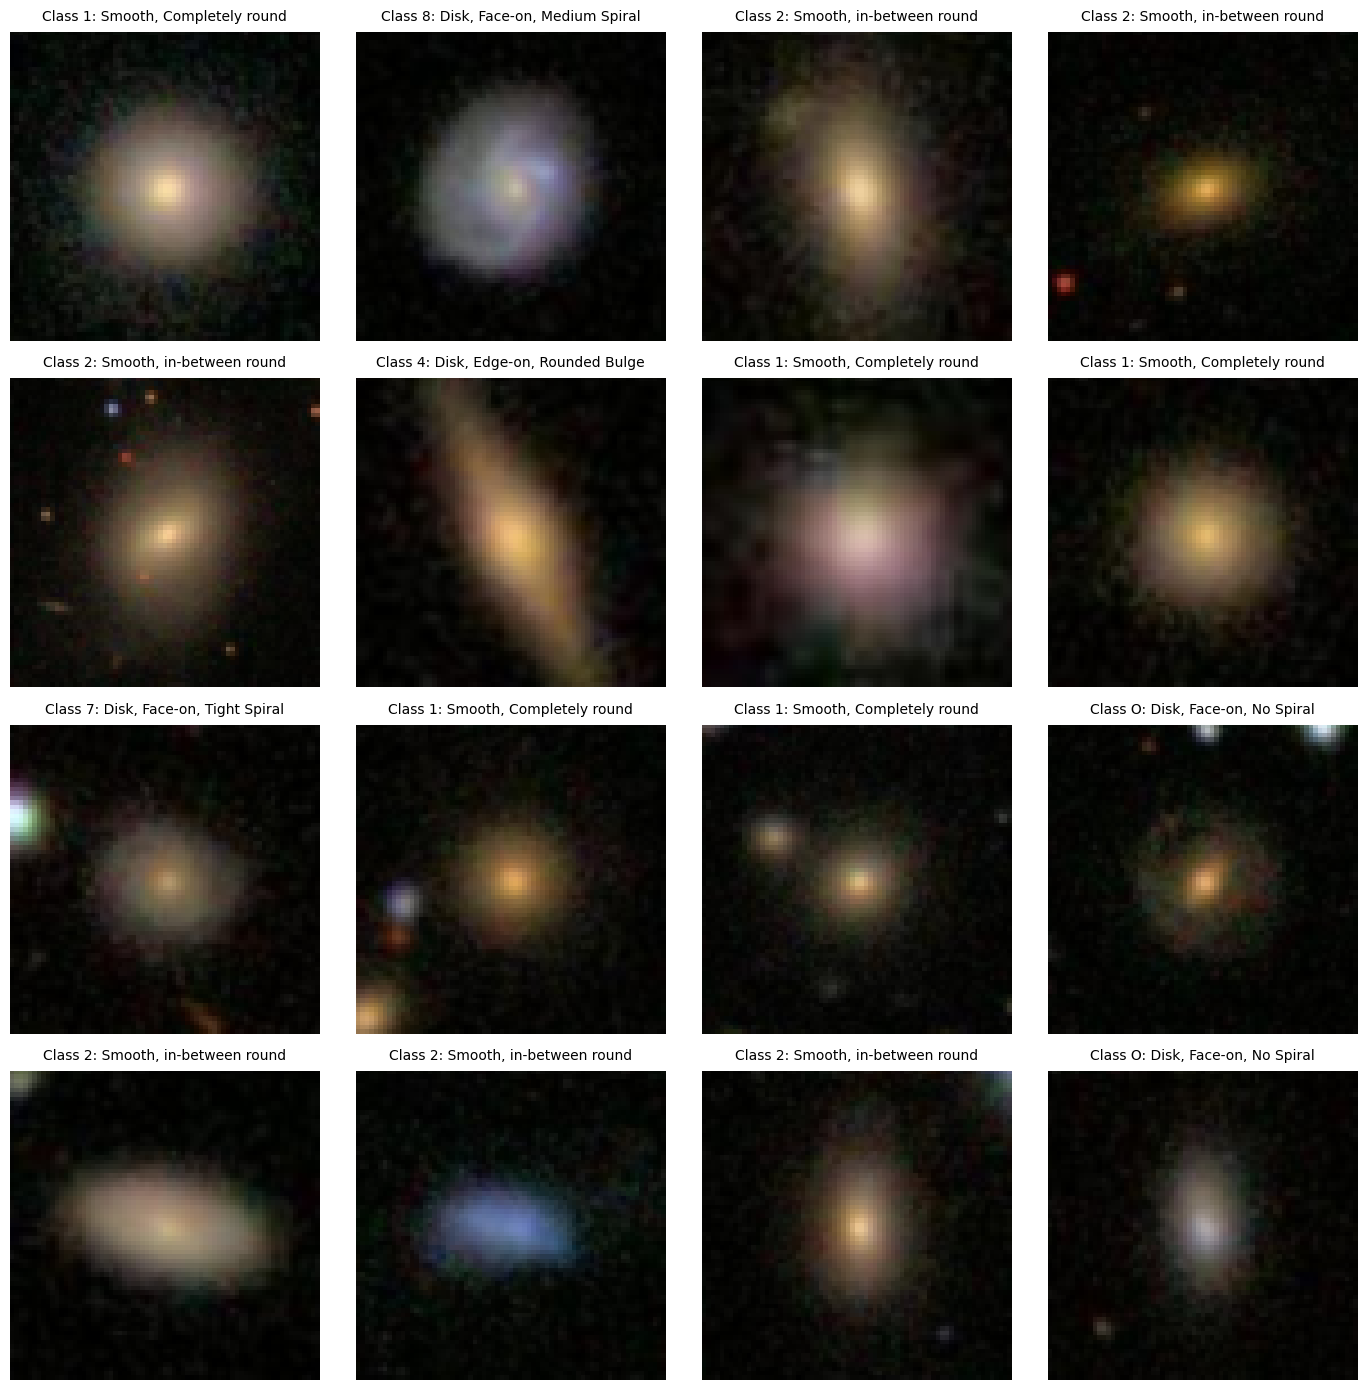

In [ ]:
#Visualization

import matplotlib.pyplot as plt

class_labels = ["Class O: Disk, Face-on, No Spiral",
                "Class 1: Smooth, Completely round",
                "Class 2: Smooth, in-between round",
                "Class 3: Smooth, Cigar shaped",
                "Class 4: Disk, Edge-on, Rounded Bulge",
                "Class 5: Disk, Edge-on, Boxy Bulge",
                "Class 6: Disk, Edge-on, No Bulge",
                "Class 7: Disk, Face-on, Tight Spiral",
                "Class 8: Disk, Face-on, Medium Spiral",
                "Class 9: Disk, Face-on, Loose Spiral"]

def plot_galaxy_grid(images, labels, class_names, grid_size=4):
    total_images = len(images)
    grid_count = grid_size * grid_size

    # Select random indices
    random_indices = np.random.choice(total_images, size=grid_count, replace=False)

    # Setup subplots
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(14, 14))
    axes = axes.flatten()

    for i, idx in enumerate(random_indices):
        img = images[idx]
        label_idx = labels[idx]
        label_text = class_names[label_idx]

        # Display image
        axes[i].imshow(img)
        axes[i].set_title(f"{label_text}", fontsize=10, pad=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer
plot_galaxy_grid(images, labels, class_labels, grid_size=4)

In [4]:
#DATA PROCESSING

import torch
import torchvision.transforms as v2

#normalize the images
images = images.astype(np.float32) / 255.0

#Class 5 skews with data due to low amount of image samples in that class
mask = (labels !=5)

images = images[mask]
labels = labels[mask]

#spliiting into 70/20/10
train_idx, test_idx = train_test_split(range(labels.shape[0]), test_size=0.2, random_state=42, stratify=labels)
train_idx, val_idx = train_test_split(train_idx, test_size=0.125, random_state=42, stratify=labels[train_idx])

#Create the actual datasets using the indices
train_images, train_labels = images[train_idx], labels[train_idx]
val_images, val_labels = images[val_idx], labels[val_idx]
test_images, test_labels = images[test_idx], labels[test_idx]

num_classes = 10

#Turns numpy array into tensorflow dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).shuffle(1000).batch(64)
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(16)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


#Optimization during training
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Remaining classes: {np.unique(labels)}")
print(f"New dataset size: {len(images)}")

Remaining classes: [0 1 2 3 4 6 7 8 9]
New dataset size: 21768


In [5]:
# Weights and Further Data Preperation

from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
sqrt_weights = np.sqrt(weights)

class_weight_dict = dict(zip(np.unique(train_labels), sqrt_weights))

print(class_weight_dict)




{np.uint8(0): np.float64(0.8358950857042893), np.uint8(1): np.float64(0.5879811821248868), np.uint8(2): np.float64(0.6199483703009626), np.uint8(3): np.float64(2.634107930621662), np.uint8(4): np.float64(1.2555278145504662), np.uint8(6): np.float64(2.0271219255315835), np.uint8(7): np.float64(1.4685666134326942), np.uint8(8): np.float64(1.6341196416280461), np.uint8(9): np.float64(2.1596091881935555)}


In [ ]:
#MODEL ARCHITECTURE

from tensorflow.keras import regularizers

# These two lines speeds up training and reduces GPU by using both 16-bit and 32-bit
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Prevents overfitting by penalizing large layer weights
l2_reg = regularizers.l2(5e-5)

model = models.Sequential([

  # Data Augmentation
  layers.RandomFlip("horizontal_and_vertical", input_shape=images.shape[1: ]),
  layers.RandomRotation(factor=.5),
  layers.RandomZoom(0.05),
  layers.RandomContrast(0.1),

  #Layers

  #using 1 by 1 first to capture more texture before using all 3 dimensions
  #Reduces memory storage
  layers.Conv2D(32, (1, 1), padding='same', use_bias=False, kernel_regularizer=l2_reg),
  layers.BatchNormalization(),
  layers.Activation('swish'), #Swish activation improves gradient flow, allowing the modle to capture features mr eeffectively
  layers.Conv2D(96, (3, 3), padding='same', use_bias=False, kernel_regularizer=l2_reg),
  layers.BatchNormalization(),
  layers.Activation('swish'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.2),

  layers.SeparableConv2D(256, (3, 3), padding='same', use_bias=False,  depthwise_regularizer=l2_reg, pointwise_regularizer=l2_reg),
  layers.BatchNormalization(),
  layers.Activation('swish'),
  layers.SeparableConv2D(256, (3, 3), padding='same', use_bias=False, depthwise_regularizer=l2_reg, pointwise_regularizer=l2_reg),
  layers.BatchNormalization(),
  layers.Activation('swish'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.3),

  layers.SeparableConv2D(256, (3, 3), padding='same', use_bias=False,  depthwise_regularizer=l2_reg, pointwise_regularizer=l2_reg),
  layers.BatchNormalization(),
  layers.Activation('swish'),

  layers.Conv2D(512, (3, 3), padding='same', use_bias=False, strides=2, kernel_regularizer=regularizers.l2(1e-4)), # this block is here to apply strides after the image is already stabalized
  layers.BatchNormalization(),
  layers.Activation('swish'),
  layers.Dropout(0.4),

  layers.SeparableConv2D(512, (3, 3), padding='same', use_bias=False, depthwise_regularizer=l2_reg, pointwise_regularizer=l2_reg),
  layers.BatchNormalization(),
  layers.Activation('swish'),

  layers.Dropout(0.4),

  #Using this pooling to capture average of features, preventing overfitting
  layers.GlobalAveragePooling2D(),

  layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5)),
  layers.BatchNormalization(),
  layers.Activation('swish'),
  layers.Dropout(0.5),

  layers.Dense(num_classes, dtype='float32'),
  layers.Activation('softmax', dtype='float32')
])



model.optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, weight_decay=1e-2)

model.compile(
    optimizer=model.optimizer,

    #to tell the model how wrong its guesses are
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),

    metrics=['accuracy']

)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,     s
    patience=4,
    min_lr=1e-6
)

early_stopping = tf.keras.callbacks.EarlyStopping( #stops model at highest val acc
    monitor='val_accuracy',
    patience=12,
    restore_best_weights=True
)

model.fit(train_ds, validation_data=val_ds, epochs=80, callbacks=[lr_schedule, early_stopping], class_weight=class_weight_dict)

# Save the model
model.save("/content/drive/MyDrive/GalaxyClassifierModel.keras")
print("Model permanently saved to your Google Drive")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Epoch 1/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 101s 228ms/step - accuracy: 0.3903 - loss: 1.6624 - val_accuracy: 0.1589 - val_loss: 2.3239 - learning_rate: 5.0000e-04
Epoch 2/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step - accuracy: 0.4626 - loss: 1.3940 - val_accuracy: 0.3206 - val_loss: 1.9802 - learning_rate: 5.0000e-04
Epoch 3/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 29s 120ms/step - accuracy: 0.5204 - loss: 1.2293 - val_accuracy: 0.5393 - val_loss: 1.2582 - learning_rate: 5.0000e-04
Epoch 4/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/step - accuracy: 0.6078 - loss: 1.0701 - val_accuracy: 0.4304 - val_loss: 1.5211 - learning_rate: 5.0000e-04
Epoch 5/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step - accuracy: 0.6673 - loss: 0.9783 - val_accuracy: 0.7157 - val_loss: 0.9448 - learning_rate: 5.0000e-04
Epoch 6/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.6993 - loss: 0.9148 - val_accuracy: 0.6477 - val_loss: 0.9810 - learning_rate: 5.0000e-04
Epoch 7/80
239/239 ━━━━━━━━━━━━━━━━━━━━ 29s 1

In [6]:
#Test Time Augmentation
#Used to create variety in the test images, which then the model averages out
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/GalaxyClassifierModel.keras")


def predict_single_image_with_tta(model, image):

    #variations
    img0 = image
    img1 = tf.image.rot90(image, k=1)
    img2 = tf.image.rot90(image, k=2)
    img3 = tf.image.rot90(image, k=3)

    img4 = tf.image.flip_left_right(img0)
    img5 = tf.image.flip_left_right(img1)
    img6 = tf.image.flip_left_right(img2)
    img7 = tf.image.flip_left_right(img3)

    tta_batch = tf.stack([img0, img1, img2, img3, img4, img5, img6, img7], axis=0)


    predictions = model.predict(tta_batch, verbose=0)

    #Averages the softmax probabilities across the 8 variations
    mean_prediction = np.mean(predictions, axis=0)

    return mean_prediction


all_standard_preds = []
all_tta_predictions = []
all_true_labels = []


for imgs_batch, labels_batch in test_ds:
    #get baseline predictions for the whole batch at once
    standard_batch_preds = model.predict(imgs_batch, verbose=0)
    all_standard_preds.extend(np.argmax(standard_batch_preds, axis=1))

    #extract numpy arrays for the TTA image processing
    imgs_np = imgs_batch.numpy()
    labels_np = labels_batch.numpy()

    for i in range(len(imgs_np)):
        single_img = imgs_np[i]
        true_label = labels_np[i]

        #Get TTA prediction

        tta_prob = predict_single_image_with_tta(model, single_img)
        tta_pred = np.argmax(tta_prob)
        all_tta_predictions.append(tta_pred)
        all_true_labels.append(true_label)


all_standard_preds = np.array(all_standard_preds)
all_tta_predictions = np.array(all_tta_predictions)
all_true_labels = np.array(all_true_labels)

# Compute accuracies
standard_accuracy = np.mean(all_standard_preds == all_true_labels)
tta_accuracy = np.mean(all_tta_predictions == all_true_labels)

print("\nFinal Test Dataset Results")
print(f"Standard Test Accuracy: {standard_accuracy * 100:.2f}%")
print(f"TTA Test Accuracy:       {tta_accuracy * 100:.2f}%")
print(f"Accuracy Boost:          {(tta_accuracy - standard_accuracy) * 100:+.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 64 variables whereas the saved optimizer has 68 variables. 



Final Test Dataset Results
Standard Test Accuracy: 87.25%
TTA Test Accuracy:       87.64%
Accuracy Boost:          +0.39%


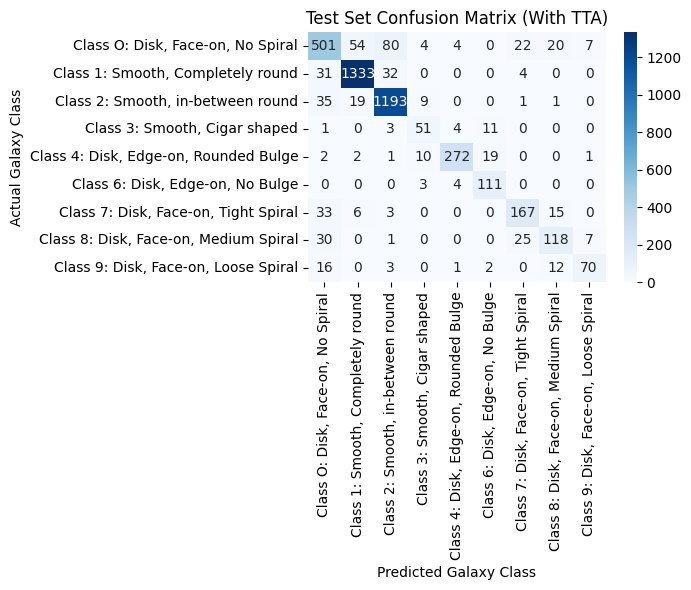

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_labels = ["Class O: Disk, Face-on, No Spiral",
                "Class 1: Smooth, Completely round",
                "Class 2: Smooth, in-between round",
                "Class 3: Smooth, Cigar shaped",
                "Class 4: Disk, Edge-on, Rounded Bulge",
                "Class 6: Disk, Edge-on, No Bulge",
                "Class 7: Disk, Face-on, Tight Spiral",
                "Class 8: Disk, Face-on, Medium Spiral",
                "Class 9: Disk, Face-on, Loose Spiral"]

cm = confusion_matrix(all_true_labels, all_tta_predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Test Set Confusion Matrix (With TTA)')
plt.ylabel('Actual Galaxy Class')
plt.xlabel('Predicted Galaxy Class')
plt.tight_layout()
plt.show()

In [7]:
#SCRIPT IS USED TO FIX PROBLEMS WITH THE FOLDER CONTAINING THE GALAXY IMAGES
import os
import shutil

def force_copy_folder(target_name):
    print("Searching Google Drive for your images folder")
    found_path = None

    #find the exact spelling match
    for root, dirs, _ in os.walk("/content/drive/MyDrive"):
        for d in dirs:
            if d.lower() == target_name.lower():
                found_path = os.path.join(root, d)
                break
        if found_path:
            break

    if not found_path:
        print("Could not locate the folder.")
        return

    print(f"Found exact path: {found_path}")
    destination = "/content/local_galaxies/galaxyZoo2ImagesCleaned"

    #remove old paths
    if os.path.exists("/content/local_galaxies"):
        shutil.rmtree("/content/local_galaxies")

    os.makedirs(destination)

    print("Copying images to fast local runtime storage")
    # Copying the images
    for file_name in os.listdir(found_path):
        src_file = os.path.join(found_path, file_name)
        if os.path.isfile(src_file):
            shutil.copy(src_file, os.path.join(destination, file_name))

    total_copied = len(os.listdir(destination))
    print(f"Forcefully copied {total_copied} images to local memory storage.")


force_copy_folder("galaxyZoo2ImagesCleaned")


Searching Google Drive for your images folder
Found exact path: /content/drive/MyDrive/Uncertain Galaxies /galaxyZoo2ImagesCleaned
Copying images to fast local runtime storage
Forcefully copied 1508 images to local memory storage.


In [8]:
#INFERENCE TEST (with TTA)
import pandas as pd

model = tf.keras.models.load_model("/content/drive/MyDrive/GalaxyClassifierModel.keras")

DATA_DIR = "/content/local_galaxies"
inference_set = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(69, 69),
    batch_size=32,
    shuffle=False, #ensures files are read in the fixed order
    label_mode=None
)

file_paths = inference_set.file_paths
file_names = [os.path.basename(path) for path in file_paths]

#So the images are formatted like galaxy_1002.jpg, and 1002 is the row number
#In the actual Truth Table, the row number of that specific uncertain galaxy is +2 of the row number in the file name
#These two lines add the +2
parsed_indices = [int(name.replace('galaxy_', '').split('.')[0]) for name in file_names]
excel_row_numbers = [idx + 2 for idx in parsed_indices]

normalization_layer = tf.keras.layers.Rescaling(1./255)
inference_set = inference_set.map(lambda x: normalization_layer(x))

tta_predictions_inference_set = []

for imgs_batch in inference_set:

    imgs_np = imgs_batch.numpy()

    for i in range(len(imgs_np)):
        single_img = imgs_np[i]

        tta_pred = predict_single_image_with_tta(model, single_img)

        tta_predictions_inference_set.append(tta_pred)

tta_predictions_inference_set = np.array(tta_predictions_inference_set)

predicted_class = np.argmax(tta_predictions_inference_set, axis=1)
confidence_scores = np.max(tta_predictions_inference_set, axis=1)

#note:class 5 as it was removed due to weighting issues
class_labels = ["Class O: Disk, Face-on, No Spiral",
                "Class 1: Smooth, Completely round",
                "Class 2: Smooth, in-between round",
                "Class 3: Smooth, Cigar shaped",
                "Class 4: Disk, Edge-on, Rounded Bulge",
                "Class 6: Disk, Edge-on, No Bulge",
                "Class 7: Disk, Face-on, Tight Spiral",
                "Class 8: Disk, Face-on, Medium Spiral",
                "Class 9: Disk, Face-on, Loose Spiral"]
predicted_labels = [class_labels[indx] for indx in predicted_class]


#save as a df
results_df = pd.DataFrame({
    "Row Number": excel_row_numbers,
    'File Name': file_names,
    'Predicted Class': predicted_labels,
    'Confidence Score': confidence_scores # Keeps the probability percentage
})

output_test_path = "/content/drive/MyDrive/galaxy_5_test_predictions_new.csv"
results_df.to_csv(output_test_path, index=False)

print(results_df)

Found 1508 files.
      Row Number          File Name                    Predicted Class  \
0         100212  galaxy_100210.jpg  Class 2: Smooth, in-between round   
1         100436  galaxy_100434.jpg  Class 2: Smooth, in-between round   
2         100507  galaxy_100505.jpg  Class 1: Smooth, Completely round   
3         100647  galaxy_100645.jpg  Class 1: Smooth, Completely round   
4         100686  galaxy_100684.jpg  Class 2: Smooth, in-between round   
...          ...                ...                                ...   
1503       99130   galaxy_99128.jpg  Class 2: Smooth, in-between round   
1504       99213   galaxy_99211.jpg  Class 2: Smooth, in-between round   
1505        9956    galaxy_9954.jpg  Class 1: Smooth, Completely round   
1506       99860   galaxy_99858.jpg  Class 2: Smooth, in-between round   
1507       99922   galaxy_99920.jpg  Class 2: Smooth, in-between round   

      Confidence Score  
0             0.525160  
1             0.524125  
2             0.50

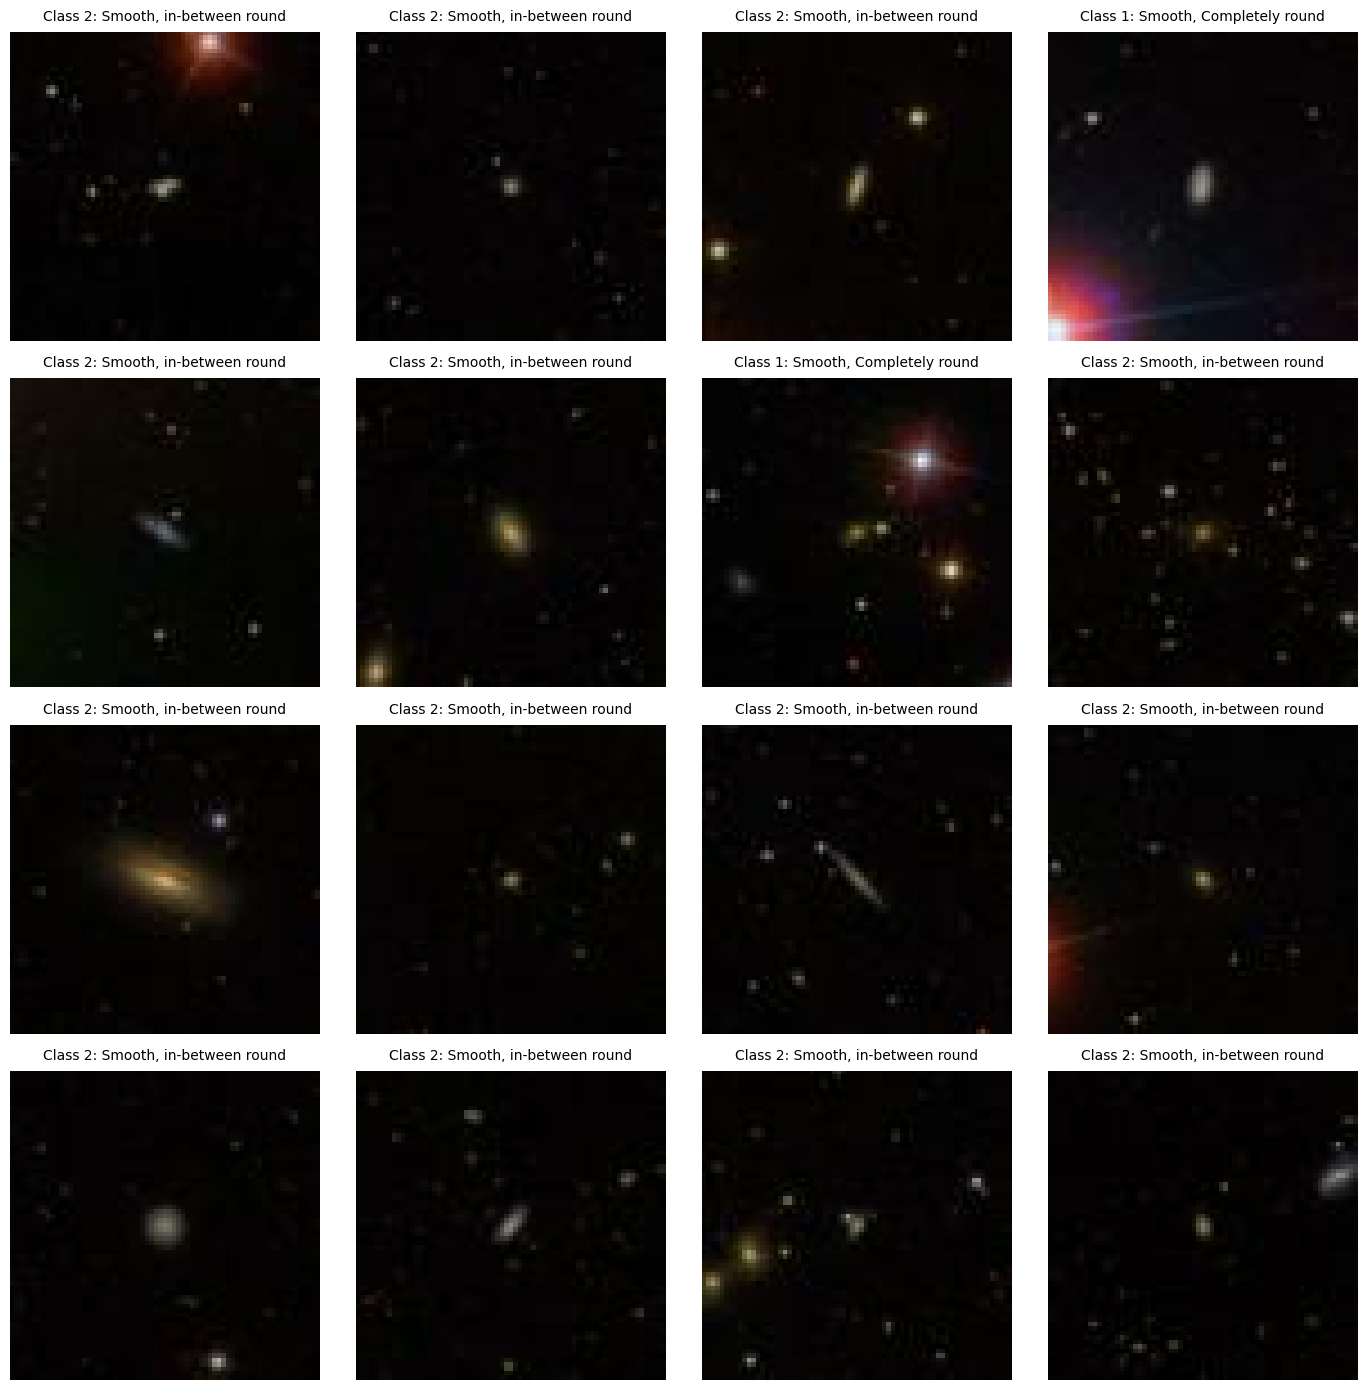

In [ ]:
#visualize inference_set

inference_images = np.concatenate([x for x in inference_set], axis=0)

plot_galaxy_grid(inference_images, predicted_class, class_labels, grid_size=4)